In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import welch
from IPython.display import Audio, display
from pynwb import NWBHDF5IO

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, IntSlider, FloatSlider, Dropdown, Checkbox

from brain_audio_decoder import BrainAudioDecoder
from custom_decoder import CustomBrainAudioDecoder
from brain_audio_decoder_viz import BrainAudioDecoderViz
from acoustic_change_detector import AcousticChangeDetector
from phoneme_validator import PhonemeValidator
from phonetic_dictionary import PhoneticDictionary
from feature_vizualizer import PhonemeFeatureVisualizer
from pipeline import UnifiedPhonemePipeline
from config import BIDS_PATH, OUTPUT_PATH, RESULTS_PATH, get_dataset_paths

Running from clean repo, using data from: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch


In [6]:
data_path = r'./Shared/Data/'  # Raw data location in their repo
paths = get_dataset_paths('dutch30')
data_dir = os.path.join(paths['data_path'], 'raw')

# Verify data first
print(f"Looking for data in: {data_dir}")
print(f"Directory exists: {os.path.exists(data_dir)}")

Looking for data in: D:\Documents\UM DACS\bachelor\UM DACS\bachelor\mozg\code\SingleWordProductionDutch\Dutch_30patients\raw
Directory exists: True


Found 150 files
Loading P01 data...
EEG shape: (307511, 130)
Channels: 130


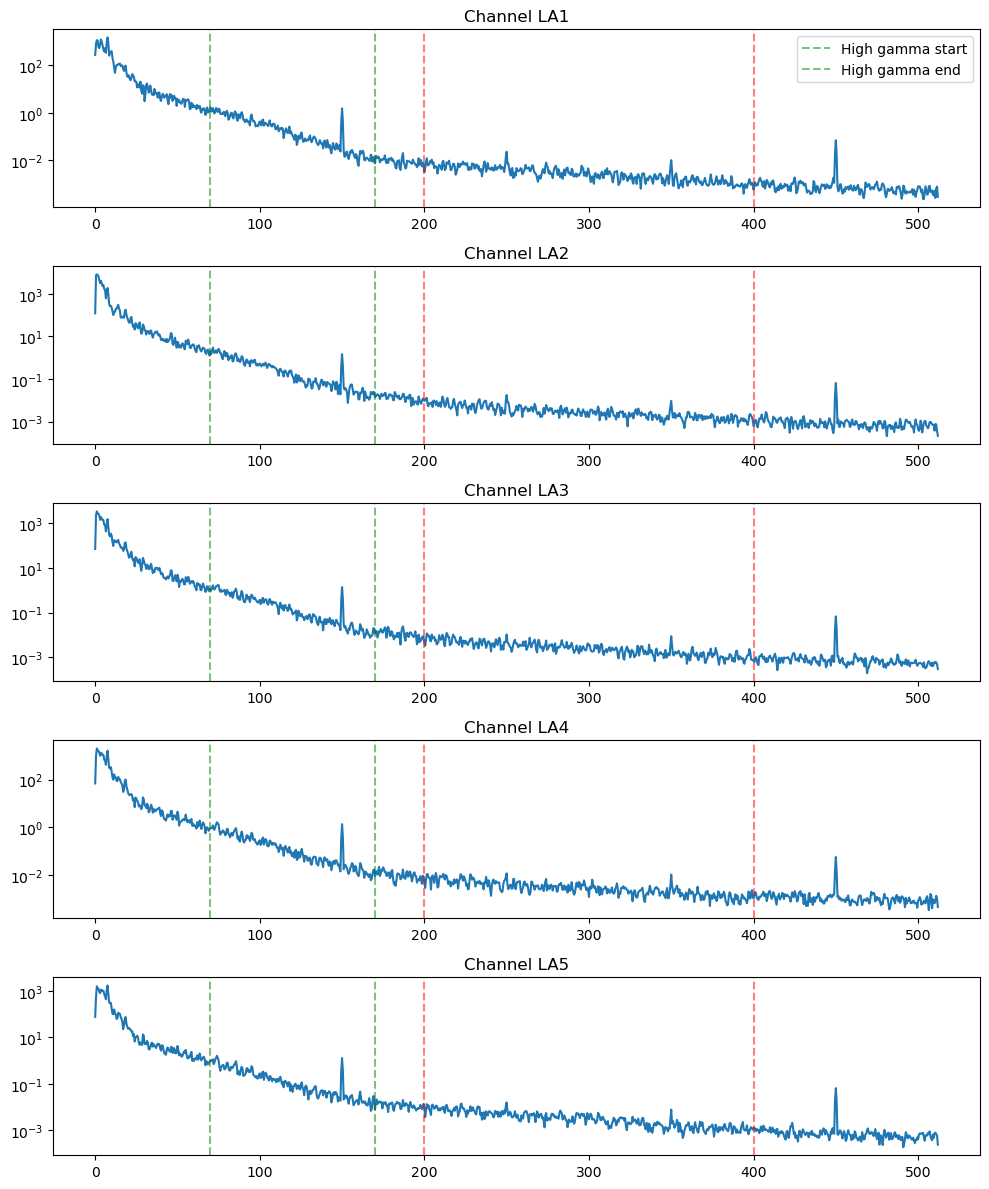

In [7]:
# Check what's there
if os.path.exists(data_dir):
    files = os.listdir(data_dir)
    print(f"Found {len(files)} files")
    
    # Check for P01
    pt_id = 'P01'
    eeg_file = os.path.join(data_dir, f'{pt_id}_sEEG.npy')
    
    if os.path.exists(eeg_file):
        print(f"Loading {pt_id} data...")
        
        # Load data
        raw_eeg = np.load(os.path.join(data_dir, f'{pt_id}_sEEG.npy'))
        channels = np.load(os.path.join(data_dir, f'{pt_id}_channels.npy'), allow_pickle=True)
        
        print(f"EEG shape: {raw_eeg.shape}")
        print(f"Channels: {len(channels)}")
        
        # Visualize first 5 channels
        fig, axes = plt.subplots(5, 1, figsize=(10, 12))
        for ch in range(min(5, raw_eeg.shape[1])):
            freqs, psd = welch(raw_eeg[:10240, ch], fs=1024, nperseg=2048)
            axes[ch].semilogy(freqs, psd)
            axes[ch].axvline(70, color='g', linestyle='--', alpha=0.5, label='High gamma start')
            axes[ch].axvline(170, color='g', linestyle='--', alpha=0.5, label='High gamma end')
            axes[ch].axvline(200, color='r', linestyle='--', alpha=0.5)
            axes[ch].axvline(400, color='r', linestyle='--', alpha=0.5)
            
            # Handle channel names properly
            if hasattr(channels[ch], '__iter__'):
                ch_name = channels[ch][0] if len(channels[ch]) > 0 else f'Ch{ch}'
            else:
                ch_name = str(channels[ch])
            
            axes[ch].set_title(f'Channel {ch_name}')
            if ch == 0:
                axes[ch].legend()
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"File not found: {eeg_file}")
else:
    print(f"Directory not found: {data_dir}")
    print("Please make sure the data files are in Dutch_30patients/raw/")

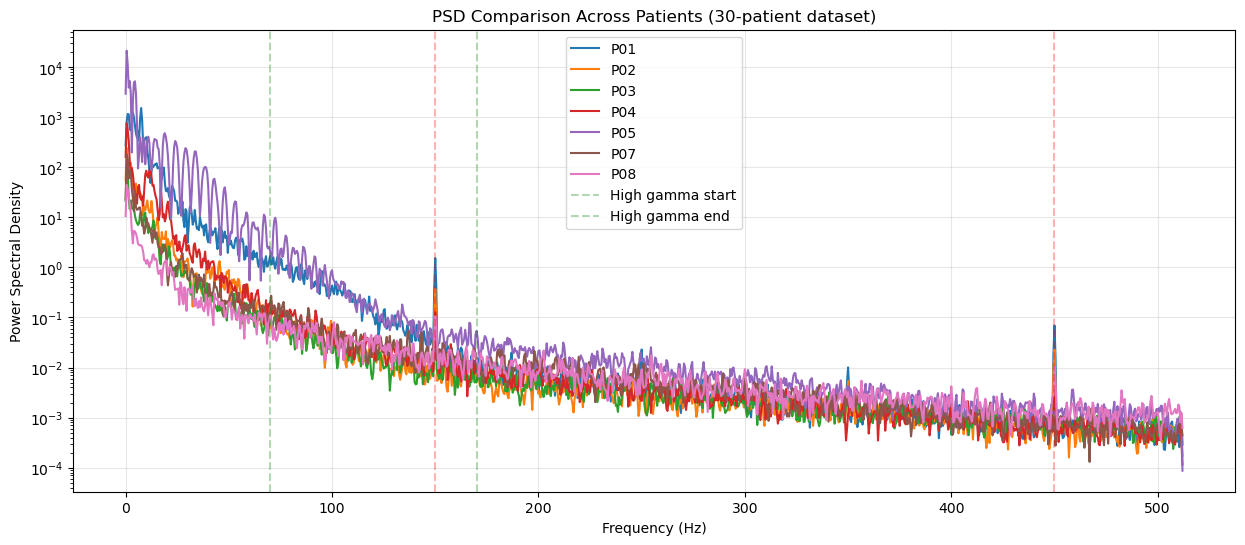

In [8]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
from config import DUTCH_30_PATH
import os

plt.figure(figsize=(15, 6))

# For 30-patient dataset (numpy format)
data_dir = os.path.join(DUTCH_30_PATH, 'raw')

# Select patients to visualize (adjust based on what you have)
patients = ['P01', 'P02', 'P03', 'P04', 'P05', 'P07', 'P08']  # or any subset

for pt_id in patients:
    eeg_file = os.path.join(data_dir, f'{pt_id}_sEEG.npy')
    
    if os.path.exists(eeg_file):
        # Load EEG data
        data = np.load(eeg_file)
        
        # Take first 10240 samples from first channel
        # (10 seconds at 1024 Hz)
        data_segment = data[:10240, 0]
        
        # Compute PSD
        freqs, psd = welch(data_segment, fs=1024, nperseg=2048)
        plt.semilogy(freqs, psd, label=pt_id)
    else:
        print(f"File not found: {eeg_file}")

# Add reference lines
plt.axvline(70, color='g', linestyle='--', alpha=0.3, label='High gamma start')
plt.axvline(170, color='g', linestyle='--', alpha=0.3, label='High gamma end')
plt.axvline(150, color='r', linestyle='--', alpha=0.3)
plt.axvline(450, color='r', linestyle='--', alpha=0.3)

plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('PSD Comparison Across Patients (30-patient dataset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np
import os
from collections import Counter
from config import DUTCH_30_PATH

# Analyze word content for 30-patient dataset
data_dir = os.path.join(DUTCH_30_PATH, 'raw')

all_words = []
patient_word_counts = {}

print("Analyzing 30-patient dataset word content:\n")
print("="*60)

for i in range(1, 31):
    pt_id = f'P{i:02d}'
    stimuli_file = os.path.join(data_dir, f'{pt_id}_stimuli.npy')
    
    if os.path.exists(stimuli_file):
        # Load stimuli
        stimuli = np.load(stimuli_file, allow_pickle=True)
        
        # Get unique words for this patient
        unique_words = np.unique(stimuli)
        
        # Filter out empty strings
        unique_words = [w for w in unique_words if w and str(w).strip()]
        
        patient_word_counts[pt_id] = len(unique_words)
        all_words.extend(unique_words)
        
        print(f"\n{pt_id}:")
        print(f"  Total markers: {len(stimuli)}")
        print(f"  Unique words: {len(unique_words)}")
        print(f"  First 10 words: {unique_words[:10]}")
        
        # Count occurrences
        word_freq = Counter(stimuli)
        most_common = word_freq.most_common(5)
        print(f"  Most frequent: {most_common}")

print("\n" + "="*60)
print("OVERALL STATISTICS:")
print("="*60)

# Overall statistics
unique_words_overall = list(set(all_words))
print(f"\nTotal unique words across all patients: {len(unique_words_overall)}")
print(f"Average words per patient: {np.mean(list(patient_word_counts.values())):.1f}")

# Show sample of vocabulary
print(f"\nSample vocabulary (first 20 words):")
print(unique_words_overall[:20])

# Check if they're Dutch words
dutch_indicators = ['van', 'de', 'het', 'een', 'en', 'is', 'dat', 'niet']
contains_dutch = any(word in unique_words_overall for word in dutch_indicators)
print(f"\nAppears to be Dutch: {contains_dutch}")

# Look for numbers
numbers = [w for w in unique_words_overall if w.isdigit() or w in ['1','2','3','4','5','6','7','8','9','10','11','12']]
if numbers:
    print(f"\nNumbers found: {numbers}")

# Create a detailed summary
print("\n" + "="*60)
print("WORD DISTRIBUTION BY PATIENT:")
print("="*60)

for pt_id, count in sorted(patient_word_counts.items()):
    bar = '█' * (count // 2)  # Simple bar chart
    print(f"{pt_id}: {count:3d} words {bar}")

Analyzing 30-patient dataset word content:


P01:
  Total markers: 307511
  Unique words: 100
  First 10 words: ['10\r', '12\r', '2\r', '3\r', '5\r', '6\r', '7\r', '8\r', '9\r', '`s morgens\r']
  Most frequent: [('', 102665), ('meisjes\r', 2057), ('3\r', 2055), ('verstijfde\r', 2055), ('op\r', 2054)]

P02:
  Total markers: 307516
  Unique words: 100
  First 10 words: ['10\r', '11\r', '12\r', '2\r', '3\r', '7\r', '8\r', '9\r', '`s morgens\r', 'aan\r']
  Most frequent: [('', 102571), ('met\r', 2056), ('te\r', 2054), ('het\r', 2054), ('ook\r', 2053)]

P03:
  Total markers: 307523
  Unique words: 100
  First 10 words: ['1\r', '11\r', '2\r', '4\r', '5\r', '7\r', '8\r', '9\r', '`s morgens\r', 'aan\r']
  Most frequent: [('', 102603), ('`s morgens\r', 2055), ('bevrijd\r', 2054), ('hij\r', 2053), ('of\r', 2053)]

P04:
  Total markers: 307521
  Unique words: 100
  First 10 words: ['10\r', '2\r', '3\r', '4\r', '5\r', '7\r', '8\r', '9\r', '`s morgens\r', 'aan\r']
  Most frequent: [('', 102587), ('


P25:
  Total markers: 512635
  Unique words: 100
  First 10 words: ['"Hallo, mijn naam is Brenda."\r', 'Aan de overkant van die berg ligt een stadje toch?\r', 'Als de lijst is afgedrukt mag je hem lamineren.\r', 'Als dessert krijgen we tiramisu.\r', 'Als je luide muziek beluisterd draag je een hoofdtelefoon.\r', 'Als zij samen praten gaat het vaak over vrouwen.\r', 'Barack Obama was de vorige Amerikaanse president.\r', 'Bepalen welke hardloper won was een kwestie van milliseconden.\r', 'Bij het ziekenhuis kwam ik een heel aardige verpleger tegen.\r', 'Breakdancen is nu weer in de mode bij jongeren.\r']
  Most frequent: [('', 102627), ('Dolfijnen communiceren en navigeren met behulp van ultrasoon geluid.\r', 4106), ('Kan je de temperatuur wat hoger zetten?\r', 4105), ('Hij was onschuldig en is vrijgesproken.\r', 4105), ('Het containerschip lag aangemeerd in de haven.\r', 4105)]

P26:
  Total markers: 512612
  Unique words: 100
  First 10 words: ['"Als het kalf verdronken is, dempt men 

In [8]:
import numpy as np
import os
from config import DUTCH_30_PATH

# Get all unique words from 30-patient dataset
data_dir = os.path.join(DUTCH_30_PATH, 'raw')

all_words_set = set()

for i in range(1, 31):
    pt_id = f'P{i:02d}'
    stimuli_file = os.path.join(data_dir, f'{pt_id}_stimuli.npy')
    
    if os.path.exists(stimuli_file):
        stimuli = np.load(stimuli_file, allow_pickle=True)
        # Add unique words, filtering out empty strings
        unique_words = [str(w).strip() for w in np.unique(stimuli) if w and str(w).strip()]
        all_words_set.update(unique_words)

# Convert to sorted list
unique_words_list = sorted(list(all_words_set))

print(f"Total unique words: {len(unique_words_list)}\n")
print("Complete word list:")
print("-" * 40)
for word in unique_words_list:
    print(word)

# Save to file if needed
output_file = os.path.join(DUTCH_30_PATH, 'unique_words.txt')
with open(output_file, 'w', encoding='utf-8') as f:
    for word in unique_words_list:
        f.write(f"{word}\n")
print(f"\nSaved to: {output_file}")

# Also save as numpy array
np.save(os.path.join(DUTCH_30_PATH, 'unique_words.npy'), unique_words_list)

Total unique words: 887

Complete word list:
----------------------------------------
"""Welterusten"" zei de moeder tegen haar kinderen."
"Als het kalf verdronken is, dempt men de put."
"Brisbane, Melbourne en Perth zijn steden in Australië."
"De vakantie was voorbij, de kinderen gingen weer naar school."
"Een atoom bestaat uit protonen, elektronen en neutronen."
"Geld heeft niet mijn interesse, macht wel!"
"Hallo, mijn naam is Brenda."
"Het is de D van Daimler, Dacia of Dodge."
"Het is de L van Land Rover, Lexus of Lotus."
"Het is wat saai, kan je een stukje doorspoelen?"
"Hij spreekt Frans, Nederlands, Engels en Duits."
"Inderdaad, we hadden meer kunnen doen om het te voorkomen."
"Ja, we gaan dat programma hervatten."
"Kan je ""Ik neem je mee"" van Gers Pardoel afspelen?"
"Kijk, ze hebben net een Sushi restaurant geopend."
"Nee, dat is niet meer het geval."
"Niemand nam op, dus ik ben zelf even langs gegaan."
"Oh heerlijk, een salade met feta."
"Pech, we zullen moeten wachten op de 

In [9]:
import numpy as np
import os
from config import DUTCH_30_PATH

data_dir = os.path.join(DUTCH_30_PATH, 'raw')

def classify_stimulus(text):
    """Classify if text is a word or sentence"""
    text = str(text).strip()
    if not text:
        return 'empty'
    # Check for sentence indicators
    if ' ' in text or len(text.split()) > 1:
        return 'sentence'
    elif len(text) > 20:  # Very long single "word" might be concatenated
        return 'possible_sentence'
    else:
        return 'word'

patient_analysis = {}

print("Patient Stimulus Type Analysis")
print("="*60)

for i in range(1, 31):
    pt_id = f'P{i:02d}'
    stimuli_file = os.path.join(data_dir, f'{pt_id}_stimuli.npy')
    
    if os.path.exists(stimuli_file):
        stimuli = np.load(stimuli_file, allow_pickle=True)
        
        # Classify each stimulus
        classifications = [classify_stimulus(s) for s in stimuli]
        
        # Count types
        n_words = classifications.count('word')
        n_sentences = classifications.count('sentence')
        n_possible = classifications.count('possible_sentence')
        n_empty = classifications.count('empty')
        
        # Get unique examples
        unique_stimuli = np.unique(stimuli)
        unique_words = [s for s in unique_stimuli if classify_stimulus(s) == 'word']
        unique_sentences = [s for s in unique_stimuli if classify_stimulus(s) == 'sentence']
        
        # Determine patient type
        if n_sentences > 0 and n_words == 0:
            patient_type = "SENTENCES ONLY"
        elif n_words > 0 and n_sentences == 0:
            patient_type = "WORDS ONLY"
        elif n_words > 0 and n_sentences > 0:
            patient_type = "MIXED"
        else:
            patient_type = "UNCLEAR"
        
        patient_analysis[pt_id] = {
            'type': patient_type,
            'n_words': n_words,
            'n_sentences': n_sentences,
            'n_unique_words': len(unique_words),
            'n_unique_sentences': len(unique_sentences),
            'example_words': unique_words[:5],
            'example_sentences': unique_sentences[:3]
        }
        
        print(f"\n{pt_id}: {patient_type}")
        print(f"  Words: {n_words} markers ({len(unique_words)} unique)")
        print(f"  Sentences: {n_sentences} markers ({len(unique_sentences)} unique)")
        if unique_words:
            print(f"  Example words: {unique_words[:5]}")
        if unique_sentences:
            print(f"  Example sentences: {unique_sentences[:2]}")

# Summary
print("\n" + "="*60)
print("SUMMARY BY PATIENT TYPE:")
print("="*60)

words_only = [p for p, info in patient_analysis.items() if info['type'] == 'WORDS ONLY']
sentences_only = [p for p, info in patient_analysis.items() if info['type'] == 'SENTENCES ONLY']
mixed = [p for p, info in patient_analysis.items() if info['type'] == 'MIXED']

print(f"\nWords Only Patients ({len(words_only)}): {words_only}")
print(f"Sentences Only Patients ({len(sentences_only)}): {sentences_only}")
print(f"Mixed Patients ({len(mixed)}): {mixed}")

# Check how markers change over time for a mixed patient
if mixed:
    print(f"\n" + "="*60)
    print(f"ANALYZING TEMPORAL PATTERN FOR {mixed[0]}:")
    print("="*60)
    
    stimuli_file = os.path.join(data_dir, f'{mixed[0]}_stimuli.npy')
    stimuli = np.load(stimuli_file, allow_pickle=True)
    
    # Look at transitions
    transitions = []
    for i in range(1, min(100, len(stimuli))):  # Look at first 100 transitions
        if stimuli[i] != stimuli[i-1]:
            type_from = classify_stimulus(stimuli[i-1])
            type_to = classify_stimulus(stimuli[i])
            transitions.append((i, stimuli[i-1], type_from, stimuli[i], type_to))
    
    print(f"First 10 stimulus changes:")
    for i, (idx, from_stim, from_type, to_stim, to_type) in enumerate(transitions[:10]):
        print(f"  {idx}: [{from_type}] '{from_stim}' -> [{to_type}] '{to_stim}'")

Patient Stimulus Type Analysis

P01: MIXED
  Words: 202794 markers (99 unique)
  Sentences: 2052 markers (1 unique)
  Example words: ['10\r', '12\r', '2\r', '3\r', '5\r']
  Example sentences: ['`s morgens\r']

P02: MIXED
  Words: 202893 markers (99 unique)
  Sentences: 2052 markers (1 unique)
  Example words: ['10\r', '11\r', '12\r', '2\r', '3\r']
  Example sentences: ['`s morgens\r']

P03: MIXED
  Words: 202865 markers (99 unique)
  Sentences: 2055 markers (1 unique)
  Example words: ['1\r', '11\r', '2\r', '4\r', '5\r']
  Example sentences: ['`s morgens\r']

P04: MIXED
  Words: 202887 markers (99 unique)
  Sentences: 2047 markers (1 unique)
  Example words: ['10\r', '2\r', '3\r', '4\r', '5\r']
  Example sentences: ['`s morgens\r']

P05: MIXED
  Words: 202873 markers (99 unique)
  Sentences: 2049 markers (1 unique)
  Example words: ['1\r', '10\r', '11\r', '2\r', '5\r']
  Example sentences: ['`s morgens\r']

P06: MIXED
  Words: 202922 markers (99 unique)
  Sentences: 2052 markers (1 uni